# Wine Classification and Model Comparison

## Proje Özeti

Bu projede, scikit-learn kütüphanesinde bulunan Wine veri seti kullanılarak şarap örneklerinin kimyasal özelliklerine göre sınıflandırılması amaçlanmıştır.

Çalışmada Logistic Regression, K-Nearest Neighbors, Decision Tree ve Random Forest modelleri karşılaştırılmıştır. Model performansları beş katlı çapraz doğrulama kullanılarak Accuracy, Precision, Recall ve F1 Score metrikleriyle değerlendirilmiştir.

## Veri Seti

Wine veri seti:

- 178 gözlem
- 13 bağımsız değişken
- 3 hedef sınıf

içermektedir. Veri setinde eksik veya tekrarlanan kayıt bulunmamaktadır.

## Uygulanan İşlemler

- Veri kalitesi kontrolü
- Keşifsel veri analizi
- Sınıf dağılımı analizi
- Korelasyon analizi
- Eğitim ve test verilerinin dengeli ayrılması
- StandardScaler ile özellik ölçeklendirme
- Dört farklı sınıflandırma modelinin karşılaştırılması
- Beş katlı çapraz doğrulama
- GridSearchCV ile hiperparametre optimizasyonu
- Confusion matrix ve ROC-AUC analizi
- Özellik önem analizi
- Modelin kaydedilmesi ve tekrar yüklenerek test edilmesi
- Streamlit tahmin uygulamasının hazırlanması

## Temel Sonuç

En başarılı model Logistic Regression olmuştur.

- Test Accuracy: **%97,22**
- Test F1 Score: **%97,10**
- Çapraz doğrulama F1 Score: **%97,96**

> Bu proje eğitim ve makine öğrenmesi portföyü amacıyla geliştirilmiştir.

In [ ]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()

data = pd.DataFrame(wine.data, columns=wine.feature_names)
data["class"] = wine.target

data

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


## Keşifsel Veri Analizi

Bu bölümde veri setinin boyutu, eksik değerleri, tekrar eden kayıtları, sınıf dağılımı ve değişkenler arasındaki ilişkiler incelenmiştir. Bu analiz, modelleme öncesinde verinin yapısını ve kalitesini anlamayı amaçlamaktadır.

In [ ]:
print("Veri setinin boyutu:", data.shape)
print("Toplam eksik değer:", data.isnull().sum().sum())
print("Tekrarlanan satır sayısı:", data.duplicated().sum())

data_quality = pd.DataFrame({
    "Veri Tipi": data.dtypes,
    "Eksik Değer": data.isnull().sum(),
    "Benzersiz Değer": data.nunique()
})

data_quality

Veri setinin boyutu: (178, 14)
Toplam eksik değer: 0
Tekrarlanan satır sayısı: 0


,Veri Tipi,Eksik Değer,Benzersiz Değer
alcohol,float64,0,126
malic_acid,float64,0,133
ash,float64,0,79
alcalinity_of_ash,float64,0,63
magnesium,float64,0,53
total_phenols,float64,0,97
flavanoids,float64,0,132
nonflavanoid_phenols,float64,0,39
proanthocyanins,float64,0,101
color_intensity,float64,0,132


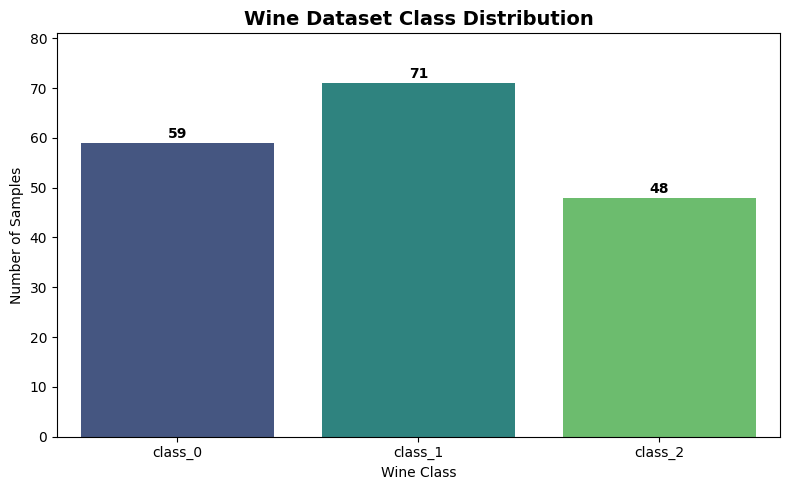

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_counts = data["class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=wine.target_names,
    y=class_counts.values,
    hue=wine.target_names,
    palette="viridis",
    legend=False
)

for index, value in enumerate(class_counts.values):
    ax.text(
        index,
        value + 1,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.title("Wine Dataset Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.ylim(0, class_counts.max() + 10)
plt.tight_layout()

plt.savefig(
    "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

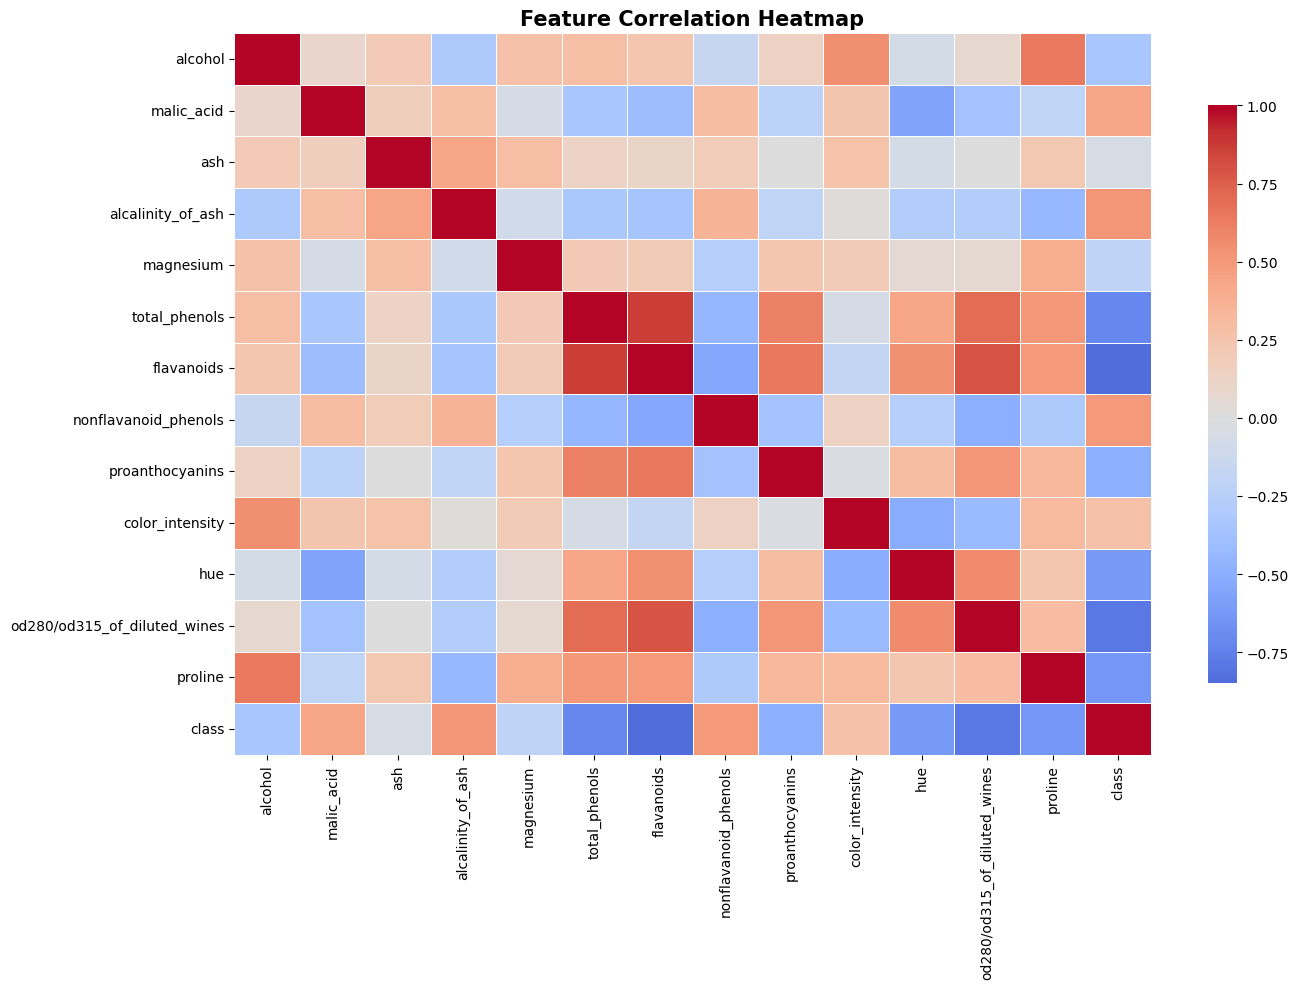

In [ ]:
correlation_matrix = data.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
X = data.drop("class", axis=1)
y = data["class"]

print("Bağımsız değişkenlerin boyutu:", X.shape)
print("Hedef değişkenin boyutu:", y.shape)

Bağımsız değişkenlerin boyutu: (178, 13)
Hedef değişkenin boyutu: (178,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Eğitim verisi:", X_train.shape)
print("Test verisi:", X_test.shape)

Eğitim verisi: (142, 13)
Test verisi: (36, 13)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=3,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

print("Karşılaştırılacak model sayısı:", len(models))

for model_name in models:
    print("-", model_name)

Karşılaştırılacak model sayısı: 4
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

model_results = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring_metrics,
        n_jobs=-1
    )

    model_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "Accuracy Std": scores["test_accuracy"].std()
    })

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Accuracy Std
0,Logistic Regression,0.9791,0.9789,0.9828,0.9796,0.0277
1,Random Forest,0.9791,0.9785,0.9828,0.9789,0.0277
2,K-Nearest Neighbors,0.9507,0.9526,0.9591,0.9512,0.0353
3,Decision Tree,0.8808,0.8911,0.8830,0.8836,0.0559


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_cv_score = results_df.iloc[0]["F1 Score"]

print("En başarılı model:", best_model_name)
print("Ortalama F1 skoru:", round(best_cv_score, 4))

En başarılı model: Logistic Regression
Ortalama F1 skoru: 0.9796


## Model Karşılaştırması ve Sonuçların Değerlendirilmesi

Bu bölümde modellerin çapraz doğrulama sonuçları görselleştirilmiş, en başarılı model test verisi üzerinde değerlendirilmiş ve sınıflandırma performansı ayrıntılı olarak incelenmiştir.

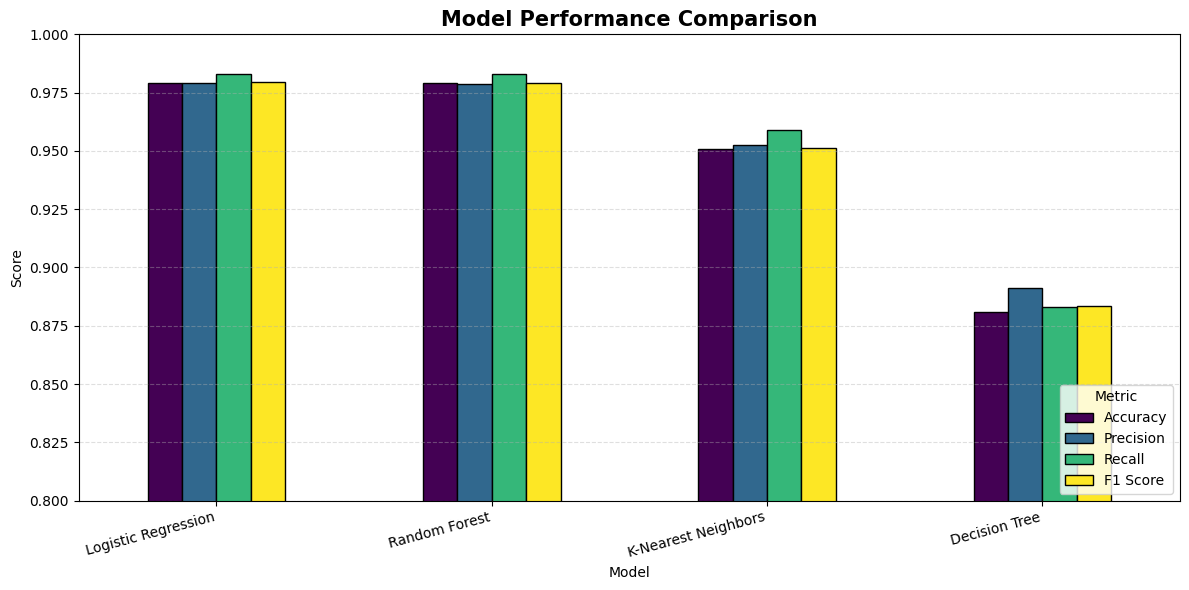

In [ ]:
import matplotlib.pyplot as plt

comparison_data = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

ax = comparison_data.plot(
    kind="bar",
    figsize=(12, 6),
    colormap="viridis",
    edgecolor="black"
)

plt.title("Model Performance Comparison", fontsize=15, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.80, 1.00)
plt.xticks(rotation=15, ha="right")
plt.legend(title="Metric", loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

best_model = models[best_model_name]

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average="macro")
test_recall = recall_score(y_test, y_pred, average="macro")
test_f1 = f1_score(y_test, y_pred, average="macro")

print("Final Model:", best_model_name)
print("-" * 40)
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test F1 Score : {test_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=wine.target_names
    )
)

Final Model: Logistic Regression
----------------------------------------
Test Accuracy : 0.9722
Test Precision: 0.9778
Test Recall   : 0.9667
Test F1 Score : 0.9710

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



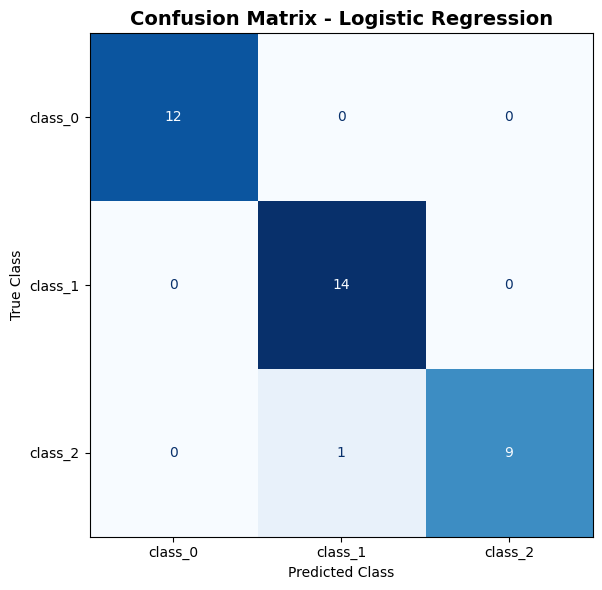

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=wine.target_names,
    cmap="Blues",
    colorbar=False,
    ax=ax
)

plt.title(
    f"Confusion Matrix - {best_model_name}",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model Optimizasyonu

Bu bölümde en başarılı modelin hiperparametreleri GridSearchCV yöntemiyle optimize edilmiştir. Optimizasyon yalnızca eğitim verisi üzerinde ve beş katlı çapraz doğrulama kullanılarak gerçekleştirilmiştir.

In [ ]:
from sklearn.model_selection import GridSearchCV

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

parameter_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["lbfgs", "newton-cg"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

final_model = grid_search.best_estimator_

print("En iyi parametreler:", grid_search.best_params_)
print("En iyi çapraz doğrulama F1 skoru:", round(grid_search.best_score_, 4))

En iyi parametreler: {'model__C': 1, 'model__solver': 'lbfgs'}
En iyi çapraz doğrulama F1 skoru: 0.9796


In [ ]:
optimized_pred = final_model.predict(X_test)

optimized_accuracy = accuracy_score(y_test, optimized_pred)
optimized_precision = precision_score(
    y_test,
    optimized_pred,
    average="macro"
)
optimized_recall = recall_score(
    y_test,
    optimized_pred,
    average="macro"
)
optimized_f1 = f1_score(
    y_test,
    optimized_pred,
    average="macro"
)

optimization_comparison = pd.DataFrame({
    "Model": [
        "Initial Logistic Regression",
        "Optimized Logistic Regression"
    ],
    "Accuracy": [
        test_accuracy,
        optimized_accuracy
    ],
    "Precision": [
        test_precision,
        optimized_precision
    ],
    "Recall": [
        test_recall,
        optimized_recall
    ],
    "F1 Score": [
        test_f1,
        optimized_f1
    ]
})

optimization_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Initial Logistic Regression,0.9722,0.9778,0.9667,0.971
1,Optimized Logistic Regression,0.9722,0.9778,0.9667,0.971


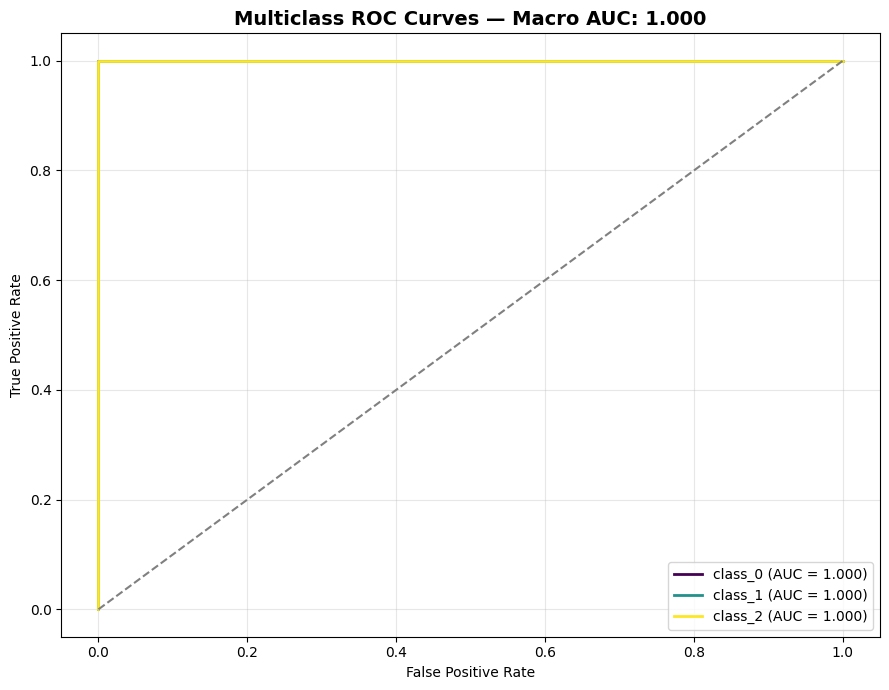

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

y_test_binary = label_binarize(
    y_test,
    classes=[0, 1, 2]
)

prediction_probabilities = final_model.predict_proba(X_test)

plt.figure(figsize=(9, 7))

colors = ["#440154", "#21918c", "#fde725"]

for class_index, color in enumerate(colors):

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_binary[:, class_index],
        prediction_probabilities[:, class_index]
    )

    class_auc = auc(
        false_positive_rate,
        true_positive_rate
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        color=color,
        linewidth=2,
        label=f"{wine.target_names[class_index]} (AUC = {class_auc:.3f})"
    )

macro_auc = roc_auc_score(
    y_test,
    prediction_probabilities,
    multi_class="ovr",
    average="macro"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.title(
    f"Multiclass ROC Curves — Macro AUC: {macro_auc:.3f}",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

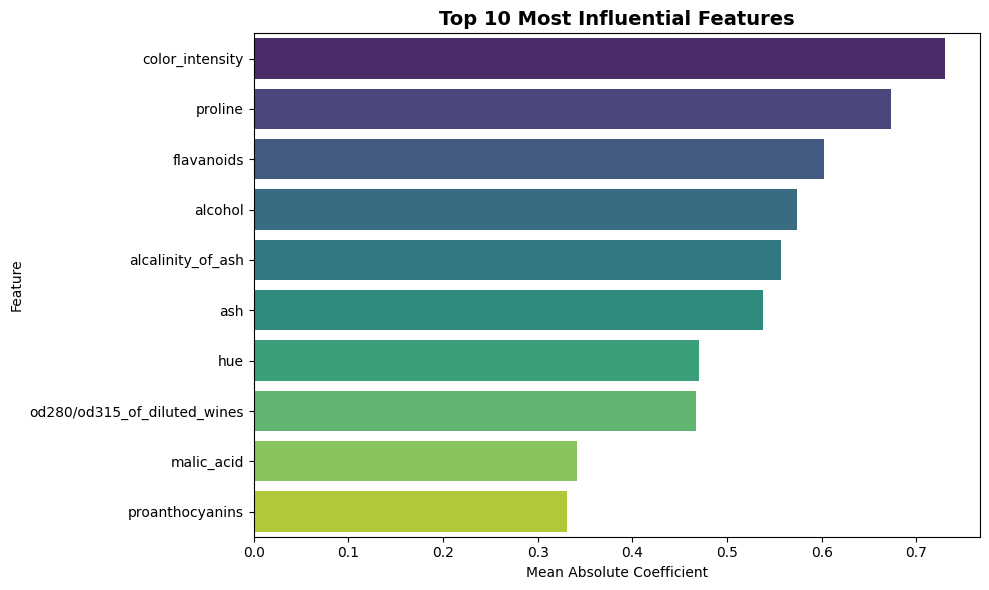

,Feature,Importance
9,color_intensity,0.730677
12,proline,0.673270
6,flavanoids,0.602310
0,alcohol,0.574358
3,alcalinity_of_ash,0.556709
2,ash,0.538171
10,hue,0.470410
11,od280/od315_of_diluted_wines,0.466792
1,malic_acid,0.341441
8,proanthocyanins,0.330515


In [ ]:
optimized_logistic_model = final_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(
        optimized_logistic_model.coef_
    ).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Most Influential Features",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

feature_importance.head(10)

In [ ]:
import joblib
import sklearn
from sklearn.base import clone

deployment_model = clone(final_model)

# Kullanıma sunulacak model artık bütün veriyle eğitiliyor.
deployment_model.fit(X, y)

model_package = {
    "model": deployment_model,
    "feature_names": X.columns.tolist(),
    "target_names": wine.target_names.tolist(),
    "feature_defaults": X.mean().to_dict(),
    "feature_minimums": X.min().to_dict(),
    "feature_maximums": X.max().to_dict(),
    "sklearn_version": sklearn.__version__
}

joblib.dump(
    model_package,
    "wine_classifier.joblib"
)

print("Model başarıyla kaydedildi.")
print("Dosya: wine_classifier.joblib")
print("Scikit-learn sürümü:", sklearn.__version__)

Model başarıyla kaydedildi.
Dosya: wine_classifier.joblib
Scikit-learn sürümü: 1.6.1


In [ ]:
loaded_package = joblib.load("wine_classifier.joblib")

loaded_model = loaded_package["model"]
feature_names = loaded_package["feature_names"]
target_names = loaded_package["target_names"]

sample = X.iloc[[0]]

sample_prediction = loaded_model.predict(sample)[0]
sample_probabilities = loaded_model.predict_proba(sample)[0]

print("Gerçek sınıf:", target_names[y.iloc[0]])
print("Tahmin edilen sınıf:", target_names[sample_prediction])

probability_table = pd.DataFrame({
    "Class": target_names,
    "Probability": sample_probabilities
})

probability_table

Gerçek sınıf: class_0
Tahmin edilen sınıf: class_0


,Class,Probability
0,class_0,0.999783
1,class_1,0.000193
2,class_2,0.000024


In [ ]:
%%writefile app.py

import joblib
import pandas as pd
import streamlit as st


st.set_page_config(
    page_title="Wine Classifier",
    page_icon="🍷",
    layout="wide"
)


@st.cache_resource
def load_model_package():
    return joblib.load("wine_classifier.joblib")


package = load_model_package()

model = package["model"]
feature_names = package["feature_names"]
target_names = package["target_names"]
feature_defaults = package["feature_defaults"]
feature_minimums = package["feature_minimums"]
feature_maximums = package["feature_maximums"]


st.title("🍷 Wine Classification Application")

st.write(
    """
    This application predicts the class of a wine sample according to
    its chemical properties. The prediction is produced using an
    optimized Logistic Regression model.
    """
)

st.info(
    "Enter the chemical measurements and press the prediction button."
)

input_values = {}

with st.form("wine_prediction_form"):

    left_column, right_column = st.columns(2)

    for index, feature in enumerate(feature_names):

        selected_column = (
            left_column if index % 2 == 0 else right_column
        )

        with selected_column:
            input_values[feature] = st.number_input(
                label=feature.replace("_", " ").title(),
                min_value=float(feature_minimums[feature]),
                max_value=float(feature_maximums[feature]),
                value=float(feature_defaults[feature]),
                format="%.4f"
            )

    predict_button = st.form_submit_button(
        "Predict Wine Class",
        use_container_width=True
    )


if predict_button:

    input_dataframe = pd.DataFrame(
        [input_values],
        columns=feature_names
    )

    prediction = model.predict(input_dataframe)[0]
    probabilities = model.predict_proba(input_dataframe)[0]

    predicted_class = target_names[prediction]

    st.success(
        f"Predicted wine class: **{predicted_class}**"
    )

    probability_dataframe = pd.DataFrame({
        "Class": target_names,
        "Probability": probabilities
    })

    st.subheader("Prediction Probabilities")
    st.dataframe(
        probability_dataframe.style.format({
            "Probability": "{:.2%}"
        }),
        use_container_width=True
    )

    st.bar_chart(
        probability_dataframe.set_index("Class")
    )


st.divider()

st.caption(
    "Developed for educational and machine-learning portfolio purposes."
)

Writing app.py


In [ ]:
%%writefile requirements.txt

streamlit>=1.40,<2.0
scikit-learn==1.6.1
pandas>=2.0,<3.0
numpy>=1.26,<3.0
joblib>=1.3,<2.0

Overwriting requirements.txt


In [ ]:
%%writefile .gitignore

__pycache__/
*.py[cod]
.venv/
venv/
env/
.ipynb_checkpoints/
.streamlit/secrets.toml
.DS_Store

Writing .gitignore


In [ ]:
%%writefile test_model.py

import joblib
import pandas as pd


def test_saved_model():

    package = joblib.load("wine_classifier.joblib")

    required_keys = {
        "model",
        "feature_names",
        "target_names",
        "feature_defaults",
        "feature_minimums",
        "feature_maximums",
        "sklearn_version"
    }

    assert required_keys.issubset(package.keys())

    model = package["model"]
    feature_names = package["feature_names"]
    target_names = package["target_names"]
    defaults = package["feature_defaults"]

    sample = pd.DataFrame(
        [[defaults[feature] for feature in feature_names]],
        columns=feature_names
    )

    prediction = model.predict(sample)[0]
    probabilities = model.predict_proba(sample)[0]

    assert len(feature_names) == 13
    assert prediction in range(len(target_names))
    assert len(probabilities) == len(target_names)
    assert abs(probabilities.sum() - 1.0) < 1e-6

    print("All model tests passed successfully.")


if __name__ == "__main__":
    test_saved_model()

Writing test_model.py


In [ ]:
!python test_model.py

All model tests passed successfully.


## Sonuç

Bu çalışmada dört farklı sınıflandırma algoritması aynı veri seti üzerinde karşılaştırılmıştır. Logistic Regression ve Random Forest modelleri en yüksek çapraz doğrulama performansını göstermiştir.

Logistic Regression modeli test verisinde %97,22 doğruluk elde etmiş ve 36 test örneğinin 35’ini doğru sınıflandırmıştır. Model optimizasyonunda en iyi parametrelerin `C=1` ve `solver=lbfgs` olduğu belirlenmiştir.

Sonuçlar, özellik ölçeklendirme ve düzenli model değerlendirme yöntemlerinin sınıflandırma başarısını önemli ölçüde artırdığını göstermektedir. Eğitilen model kaydedilmiş, otomatik testten geçirilmiş ve Streamlit tabanlı tahmin uygulamasında kullanılmaya hazır hâle getirilmiştir.